In [1]:
import numpy as np
import quantile_forest as qrf

## Naujas eksperimentas

In [2]:
x = np.load('../anom-x.npy')
y = np.load('../anom-y.npy')

x_rev = np.load('../anom-x-reverse.npy')
y_rev = np.load('../anom-y-reverse.npy')

In [16]:
y_pred_cog = np.load('../anom-pred-qrf-cog.npy', allow_pickle=True)
y_pred_dif = np.load('../anom-pred-qrf-dif.npy', allow_pickle=True)

y_low, y_high = y_pred_cog[:, 0], y_pred_cog[:, 1]

In [6]:
import pandas as pd

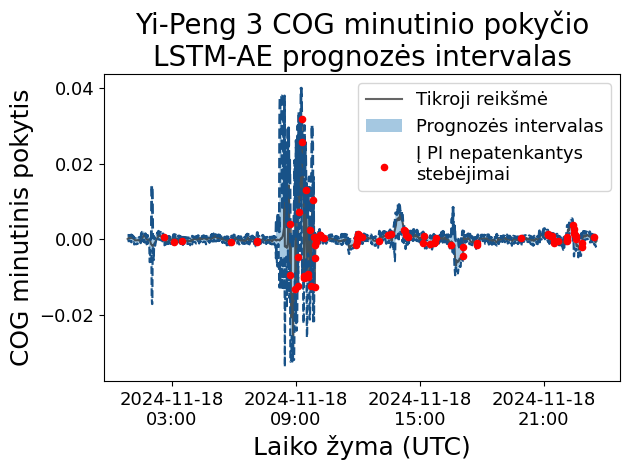

In [17]:
from datetime import datetime
import matplotlib.pyplot as plt
timestamps = list(pd.date_range(start=datetime(2024,11,18,0,0), end=datetime(2024,11,19,0,0), freq='60s')[51:-26])

anomalies_x = []
anomalies_y = []
y_flat = y[:, 0, 0].ravel()

for i in range(y.shape[0]):

    if y[i, 0, 0].ravel() < y_low[i]:
        anomalies_x.append( timestamps[i] )
        anomalies_y.append( y_flat[i] )

    elif y[i, 0, 0].ravel() > y_high[i]:
        anomalies_x.append( timestamps[i] )
        anomalies_y.append( y_flat[i] )

plt.plot(timestamps, y[:, 0, 0].ravel(), label = "Tikroji reikšmė", color='black', alpha=0.6)
plt.plot(timestamps, y_high.ravel(), color='#185288', linestyle='--', linewidth=2)
plt.plot(timestamps, y_low.ravel(), color="#185288", linestyle='--')

plt.xticks(
    ticks=[datetime(2024,11,18, 3+x*6,0) for x in range(0, 4)],
    labels=[f"2024-11-18\n{(3+x*6):02}:00" for x in range(0, 4)],
)
plt.tick_params(axis='both', which='both', labelsize=13)

plt.xlabel('Laiko žyma (UTC)', size=18)
plt.ylabel('COG minutinis pokytis', size=18)
plt.title('Yi-Peng 3 COG minutinio pokyčio\nLSTM-AE prognozės intervalas', size=20)

plt.fill_between(timestamps, y1=y_low.ravel(), y2=y_high.ravel(), alpha=0.4, label='Prognozės intervalas')
plt.scatter(anomalies_x, anomalies_y, color='red', s=20, alpha=1.0, label='Į PI nepatenkantys\nstebėjimai', zorder=5)
plt.legend(fontsize=13)

plt.tight_layout()
plt.savefig("cog-difference-res-qrf.png", dpi=750)

plt.show()

In [18]:
should_capture = np.array(timestamps) > datetime(2024,11,18,8,30)

y_flat = y[should_capture, 0, 0].ravel()
y_high_an = y_high[should_capture].ravel()
y_low_an = y_low[should_capture].ravel()

np.mean( (y_flat < y_high_an) & (y_flat > y_low_an) )

np.float64(0.9236725663716814)

In [19]:
y_low_dif, y_high_dif = y_pred_dif[:, 0], y_pred_dif[:, 1]

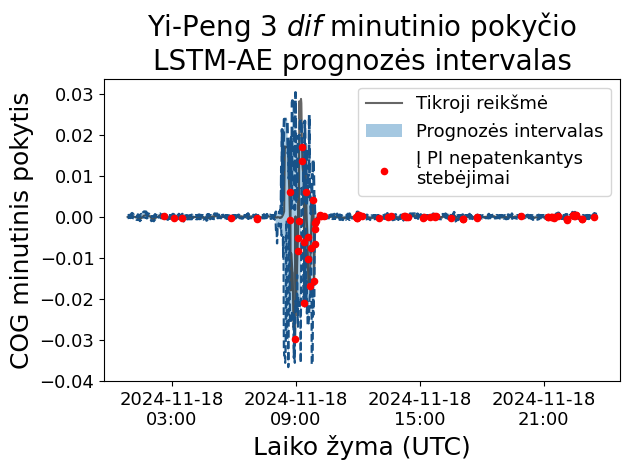

In [20]:
from datetime import datetime
import matplotlib.pyplot as plt
timestamps = list(pd.date_range(start=datetime(2024,11,18,0,0), end=datetime(2024,11,19,0,0), freq='60s')[51:-26])

anomalies_x = []
anomalies_y = []
y_flat = y[:, 0, 1].ravel()

for i in range(y.shape[0]):

    if y[i, 0, 0].ravel() < y_low[i]:
        anomalies_x.append( timestamps[i] )
        anomalies_y.append( y_flat[i] )

    elif y[i, 0, 0].ravel() > y_high[i]:
        anomalies_x.append( timestamps[i] )
        anomalies_y.append( y_flat[i] )

plt.plot(timestamps, y[:, 0, 1].ravel(), label = "Tikroji reikšmė", color='black', alpha=0.6)
plt.plot(timestamps, y_high_dif.ravel(), color='#185288', linestyle='--', linewidth=2)
plt.plot(timestamps, y_low_dif.ravel(), color="#185288", linestyle='--')

plt.xticks(
    ticks=[datetime(2024,11,18, 3+x*6,0) for x in range(0, 4)],
    labels=[f"2024-11-18\n{(3+x*6):02}:00" for x in range(0, 4)],
)
plt.tick_params(axis='both', which='both', labelsize=13)

plt.xlabel('Laiko žyma (UTC)', size=18)
plt.ylabel('COG minutinis pokytis', size=18)
plt.title('Yi-Peng 3 $dif$ minutinio pokyčio\nLSTM-AE prognozės intervalas', size=20)

plt.fill_between(timestamps, y1=y_low_dif.ravel(), y2=y_high_dif.ravel(), alpha=0.4, label='Prognozės intervalas')
plt.scatter(anomalies_x, anomalies_y, color='red', s=20, alpha=1.0, label='Į PI nepatenkantys\nstebėjimai', zorder=5)
plt.legend(fontsize=13)

plt.tight_layout()
plt.savefig("dif-difference-res-qrf.png", dpi=750)

plt.show()

In [21]:
should_capture = np.array(timestamps) > datetime(2024,11,18,8,30)

y_flat = y[should_capture, 0, 0].ravel()
y_high_an = y_high_dif[should_capture].ravel()
y_low_an = y_low_dif[should_capture].ravel()

np.mean( (y_flat < y_high_an) & (y_flat > y_low_an) )

np.float64(0.4944690265486726)

In [17]:
np.mean( (y_flat > y_low_dif) & (y_flat < y_high_dif) )

np.float64(0.9780058651026393)

In [21]:
np.mean( (y[:, 0, 0] > y_low) & (y[:, 0, 0] < y_high) )

np.float64(0.9538123167155426)

In [24]:
X_test = np.load('../X_test_final.npy')
y_test = np.load('../y_test_final.npy')

X_test = X_test.reshape((-1, X_test.shape[1]*X_test.shape[2]))
y_test_cog = y_test[:, 0, 0].ravel()
y_test_dif = y_test[:, 0, 1].ravel()

In [27]:
y_pred_cog = qrf_model_cog.predict(X_test, quantiles=[0.025, 0.975])
y_pred_dif = qrf_model_dif.predict(X_test, quantiles=[0.025, 0.975])

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 128 out of 128 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 128 out of 128 | elapsed:    0.2s finished


In [31]:
y_low_cog, y_high_cog = y_pred_cog[:, 0], y_pred_cog[:, 1]
y_low_dif, y_high_dif = y_pred_dif[:, 0], y_pred_dif[:, 1]

In [37]:
np.mean( (y_test_cog > y_low_cog) & (y_test_cog < y_high_cog) )

np.float64(0.947741423595702)

In [36]:
np.mean( (y_test_dif > y_low_dif) & (y_test_dif < y_high_dif) )

np.float64(0.9463159451863208)